In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
factors = [
    "F1","F2","F3","F4","F5",
    "F6","F7","F8","F9","F10",
    "F11","F12","F13","F14","F15"
]

n = len(factors)

In [4]:
fuzzy_scale = {
    "N": (0.00, 0.00, 0.00),
    "L": (0.00, 0.25, 0.50),
    "M": (0.25, 0.50, 0.75),
    "H": (0.50, 0.75, 1.00),
    "VH": (0.75, 1.00, 1.00)
}

In [5]:
file_path = "expert_responses.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15']


CURRENT WORKING DIRECTORY
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding

CHECKING INPUT FILE
Expected input:
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding\expert_responses.xlsx

✓ Input file found.

Output folder:
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding\output

✓ Output folder is ready.

EXCEL SHEETS
E1
E2
E3
E4
E5
E6
E7
E8
E9
E10
E11
E12
E13
E14
E15

Number of sheets: 15

READING EXPERT MATRICES
Reading: E1
Reading: E2
Reading: E3
Reading: E4
Reading: E5
Reading: E6
Reading: E7
Reading: E8
Reading: E9
Reading: E10
Reading: E11
Reading: E12
Reading: E13
Reading: E14
Reading: E15

✓ All expert matrices successfully read.

DATA DIMENSIONS
Linguistic matrices: (15, 15, 15)
Fuzzy matrices: (15, 15, 15, 3)

DIRECT RELATION MATRIX
         F1      F2      F3      F4      F5      F6    

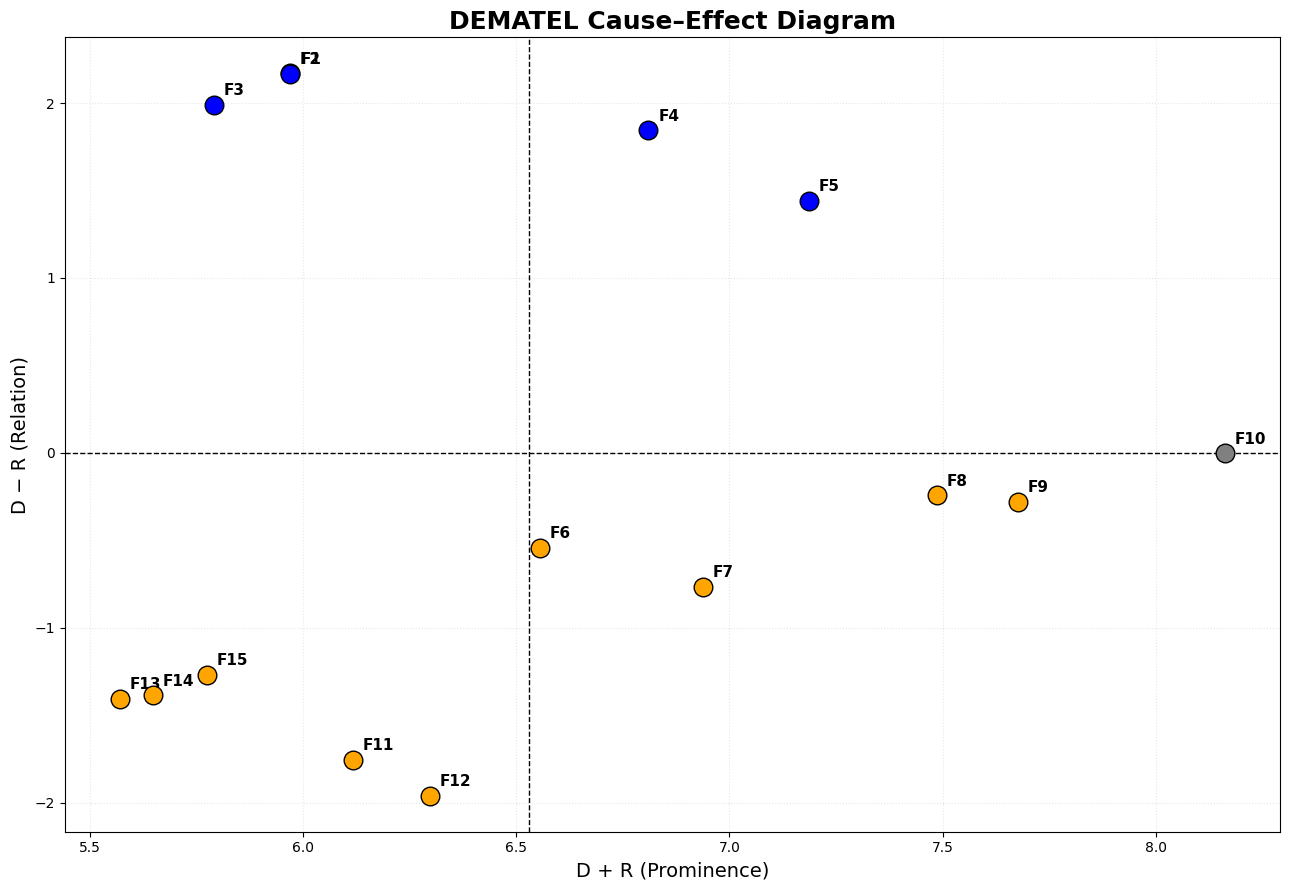


✓ Cause-effect diagram saved:
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding\output\DEMATEL_Cause_Effect_Diagram.png


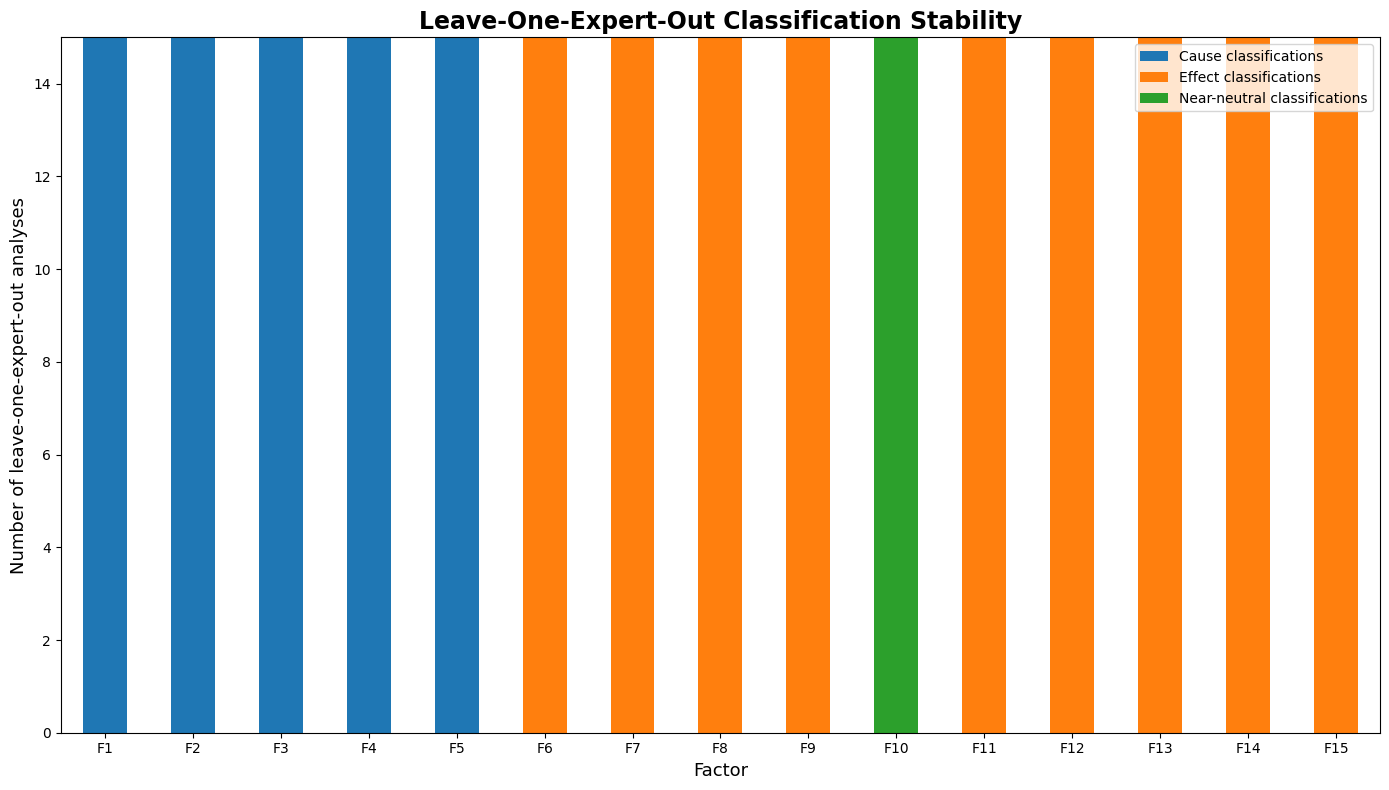


✓ Sensitivity figure saved:
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding\output\DEMATEL_Sensitivity_Cause_Effect.png

FINAL DEMATEL RESULTS

Factor      D      R    D+R     D-R        Classification
    F1 4.0705 1.9006 5.9711  2.1699                 Cause
    F2 4.0682 1.9006 5.9688  2.1675                 Cause
    F3 3.8905 1.9018 5.7924  1.9887                 Cause
    F4 4.3272 2.4832 6.8104  1.8439                 Cause
    F5 4.3150 2.8727 7.1877  1.4423                 Cause
    F6 3.0058 3.5503 6.5560 -0.5445                Effect
    F7 3.0859 3.8519 6.9379 -0.7660                Effect
    F8 3.6220 3.8647 7.4867 -0.2426                Effect
    F9 3.6983 3.9774 7.6757 -0.2791                Effect
   F10 4.0793 4.0823 8.1617 -0.0030 Near-neutral / bridge
   F11 2.1810 3.9370 6.1180 -1.7560                Effect
   F12 2.1690 4.1294 6.2984 -1.9604                Effect
   F13 2.0828 3.4886 5.5714 -1.4058

In [6]:
# ============================================================
# COMPLETE FUZZY LINGUISTIC + CRISP DEMATEL ANALYSIS
# ============================================================
#
# INPUT:
#     exper_responses.xlsx
#
# INPUT LOCATION:
#     Same folder as the Jupyter Notebook / current working folder
#
# OUTPUT:
#     output/
#
# MAIN FUZZY SCALE:
#     N   = (0.00, 0.00, 0.00)
#     L   = (0.00, 0.25, 0.50)
#     M   = (0.25, 0.50, 0.75)
#     H   = (0.50, 0.75, 1.00)
#     VH  = (0.75, 1.00, 1.00)
#
# PROCEDURE:
#
# 1. Read 15 expert matrices
# 2. Validate data
# 3. Convert linguistic values to TFNs
# 4. Aggregate expert TFNs
# 5. Centroid defuzzification
# 6. Direct Relation Matrix
# 7. DEMATEL normalization
# 8. Total Relation Matrix
# 9. D, R, D+R, D-R
# 10. Cause / Effect / Near-neutral classification
# 11. Expert response frequencies
# 12. Expert-level summary
# 13. Leave-one-expert-out sensitivity analysis
# 14. Alternative "No influence" sensitivity analysis
# 15. Export all results to Excel
# 16. Generate figures
#
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. DEFINE WORKING DIRECTORY
# ============================================================

# IMPORTANT:
# Path.cwd() gives the current working directory of Jupyter.

BASE_DIR = Path.cwd()

print("=" * 70)
print("CURRENT WORKING DIRECTORY")
print("=" * 70)

print(BASE_DIR)

print()


# ============================================================
# 2. DEFINE INPUT FILE
# ============================================================

INPUT_FILE = BASE_DIR / "expert_responses.xlsx"


# ============================================================
# 3. DEFINE OUTPUT FOLDER
# ============================================================

OUTPUT_DIR = BASE_DIR / "output"

# Create output folder if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 4. DEFINE OUTPUT FILES
# ============================================================

OUTPUT_EXCEL = (
    OUTPUT_DIR /
    "DEMATEL_Complete_Analysis.xlsx"
)

CAUSE_EFFECT_FIGURE = (
    OUTPUT_DIR /
    "DEMATEL_Cause_Effect_Diagram.png"
)

SENSITIVITY_FIGURE = (
    OUTPUT_DIR /
    "DEMATEL_Sensitivity_Cause_Effect.png"
)


# ============================================================
# 5. CHECK INPUT FILE
# ============================================================

print("=" * 70)
print("CHECKING INPUT FILE")
print("=" * 70)

print("Expected input:")
print(INPUT_FILE)

print()

if not INPUT_FILE.exists():

    print("ERROR: Input file was not found.")
    print()
    print("Files currently available in the working directory:")
    print()

    for item in BASE_DIR.iterdir():
        print("   ", item.name)

    raise FileNotFoundError(
        "\nCould not find 'expert_responses.xlsx'.\n"
        "Make sure the Excel file is in the same folder "
        "as the Jupyter working directory."
    )

else:

    print("✓ Input file found.")


print()

print("Output folder:")
print(OUTPUT_DIR)

print()

if OUTPUT_DIR.exists():

    print("✓ Output folder is ready.")

print()


# ============================================================
# 6. FACTOR NAMES
# ============================================================

factors = [
    "F1",
    "F2",
    "F3",
    "F4",
    "F5",
    "F6",
    "F7",
    "F8",
    "F9",
    "F10",
    "F11",
    "F12",
    "F13",
    "F14",
    "F15"
]

n = len(factors)


# ============================================================
# 7. MAIN FUZZY LINGUISTIC SCALE
# ============================================================
#
# IMPORTANT:
#
# We use:
#
# N = (0,0,0)
#
# This means "No influence" remains zero after
# defuzzification.
#
# This directly addresses Reviewer 2's concern.
#
# ============================================================

FUZZY_SCALE = {

    "N": (
        0.00,
        0.00,
        0.00
    ),

    "L": (
        0.00,
        0.25,
        0.50
    ),

    "M": (
        0.25,
        0.50,
        0.75
    ),

    "H": (
        0.50,
        0.75,
        1.00
    ),

    "VH": (
        0.75,
        1.00,
        1.00
    )

}


# ============================================================
# 8. OPEN EXCEL FILE
# ============================================================

excel_file = pd.ExcelFile(
    INPUT_FILE
)

sheet_names = excel_file.sheet_names


print("=" * 70)
print("EXCEL SHEETS")
print("=" * 70)

for sheet in sheet_names:
    print(sheet)

print()

print("Number of sheets:", len(sheet_names))

print()


# ============================================================
# 9. CHECK NUMBER OF EXPERTS
# ============================================================

if len(sheet_names) != 15:

    raise ValueError(
        f"\nExpected 15 expert sheets, "
        f"but found {len(sheet_names)}."
    )


# ============================================================
# 10. CREATE STORAGE
# ============================================================

expert_linguistic_matrices = []

expert_fuzzy_matrices = []


# ============================================================
# 11. READ ALL EXPERT MATRICES
# ============================================================

print("=" * 70)
print("READING EXPERT MATRICES")
print("=" * 70)

for sheet in sheet_names:

    print("Reading:", sheet)

    df = pd.read_excel(
        excel_file,
        sheet_name=sheet
    )


    # --------------------------------------------------------
    # Expected columns
    # --------------------------------------------------------

    expected_columns = [
        "From/To"
    ] + factors


    if list(df.columns) != expected_columns:

        raise ValueError(
            f"\nProblem in sheet: {sheet}\n\n"
            f"Expected columns:\n"
            f"{expected_columns}\n\n"
            f"Actual columns:\n"
            f"{list(df.columns)}"
        )


    # --------------------------------------------------------
    # Expected dimensions
    # --------------------------------------------------------

    if df.shape != (15, 16):

        raise ValueError(
            f"\nProblem in sheet: {sheet}\n"
            f"Expected 15 rows x 16 columns.\n"
            f"Actual size: {df.shape}"
        )


    # --------------------------------------------------------
    # Check row labels
    # --------------------------------------------------------

    row_labels = (
        df["From/To"]
        .astype(str)
        .str.strip()
        .tolist()
    )


    if row_labels != factors:

        raise ValueError(
            f"\nProblem in sheet: {sheet}\n"
            f"Row labels are not F1-F15.\n\n"
            f"Found:\n{row_labels}"
        )


    # --------------------------------------------------------
    # Extract linguistic matrix
    # --------------------------------------------------------

    linguistic_df = df[
        factors
    ].copy()


    # --------------------------------------------------------
    # Clean linguistic values
    # --------------------------------------------------------

    linguistic_df = linguistic_df.apply(

        lambda column:
        column
        .astype(str)
        .str.strip()
        .str.upper()

    )


    # --------------------------------------------------------
    # Check valid values
    # --------------------------------------------------------

    valid_values = set(
        FUZZY_SCALE.keys()
    )

    observed_values = set(
        linguistic_df
        .to_numpy()
        .flatten()
    )

    invalid_values = (
        observed_values
        -
        valid_values
    )


    if invalid_values:

        raise ValueError(
            f"\nInvalid linguistic values in {sheet}:\n"
            f"{sorted(invalid_values)}\n\n"
            f"Allowed values:\n"
            f"{sorted(valid_values)}"
        )


    # --------------------------------------------------------
    # Store linguistic matrix
    # --------------------------------------------------------

    expert_linguistic_matrices.append(
        linguistic_df.to_numpy()
    )


    # --------------------------------------------------------
    # Convert to fuzzy numbers
    # --------------------------------------------------------

    fuzzy_matrix = np.zeros(
        (n, n, 3),
        dtype=float
    )


    for i in range(n):

        for j in range(n):

            linguistic_value = (
                linguistic_df.iloc[i, j]
            )

            fuzzy_matrix[i, j, :] = (
                FUZZY_SCALE[
                    linguistic_value
                ]
            )


    # --------------------------------------------------------
    # Force diagonal to zero
    # --------------------------------------------------------

    for i in range(n):

        fuzzy_matrix[i, i, :] = (
            0.00,
            0.00,
            0.00
        )


    # --------------------------------------------------------
    # Store fuzzy matrix
    # --------------------------------------------------------

    expert_fuzzy_matrices.append(
        fuzzy_matrix
    )


print()

print("✓ All expert matrices successfully read.")


# ============================================================
# 12. CONVERT TO NUMPY ARRAYS
# ============================================================

expert_linguistic_matrices = np.asarray(
    expert_linguistic_matrices
)

expert_fuzzy_matrices = np.asarray(
    expert_fuzzy_matrices
)


print()
print("=" * 70)
print("DATA DIMENSIONS")
print("=" * 70)

print(
    "Linguistic matrices:",
    expert_linguistic_matrices.shape
)

print(
    "Fuzzy matrices:",
    expert_fuzzy_matrices.shape
)

print()


# ============================================================
# 13. AGGREGATE 15 EXPERTS
# ============================================================
#
# Arithmetic mean of lower, middle and upper fuzzy values.
#
# ============================================================

aggregated_fuzzy_matrix = (
    expert_fuzzy_matrices.mean(
        axis=0
    )
)


# ============================================================
# 14. DEFUZZIFICATION
# ============================================================
#
# Centroid:
#
# Crisp value =
#
# (L + M + U) / 3
#
# ============================================================

direct_relation_matrix = (
    aggregated_fuzzy_matrix.mean(
        axis=2
    )
)


# Ensure diagonal = 0

np.fill_diagonal(
    direct_relation_matrix,
    0.0
)


# ============================================================
# 15. DIRECT RELATION MATRIX
# ============================================================

direct_relation_df = pd.DataFrame(

    direct_relation_matrix,

    index=factors,

    columns=factors

)


print("=" * 70)
print("DIRECT RELATION MATRIX")
print("=" * 70)

print(
    direct_relation_df.round(4)
)

print()


# ============================================================
# 16. DEMATEL NORMALIZATION
# ============================================================
#
# s =
# maximum of the maximum row sum and maximum column sum
#
# N = X / s
#
# ============================================================

row_sums = (
    direct_relation_matrix
    .sum(axis=1)
)

column_sums = (
    direct_relation_matrix
    .sum(axis=0)
)


normalization_factor = max(

    row_sums.max(),

    column_sums.max()

)


if normalization_factor <= 0:

    raise ValueError(
        "Normalization factor is zero. "
        "Check the direct relation matrix."
    )


normalized_matrix = (
    direct_relation_matrix
    /
    normalization_factor
)


normalized_df = pd.DataFrame(

    normalized_matrix,

    index=factors,

    columns=factors

)


# ============================================================
# 17. CONVERGENCE CHECK
# ============================================================

eigenvalues = np.linalg.eigvals(
    normalized_matrix
)

spectral_radius = max(
    abs(eigenvalues)
)


print("=" * 70)
print("NORMALIZATION CHECK")
print("=" * 70)

print(
    "Normalization factor:",
    round(
        float(normalization_factor),
        6
    )
)

print(
    "Spectral radius:",
    round(
        float(spectral_radius),
        6
    )
)

print()


if spectral_radius >= 1:

    raise ValueError(
        "DEMATEL convergence condition failed.\n"
        "Spectral radius must be less than 1."
    )

else:

    print(
        "✓ DEMATEL convergence condition satisfied."
    )

print()


# ============================================================
# 18. TOTAL RELATION MATRIX
# ============================================================
#
# T = N (I-N)^(-1)
#
# ============================================================

I = np.identity(n)


total_relation_matrix = (

    normalized_matrix

    @

    np.linalg.inv(
        I - normalized_matrix
    )

)


total_relation_df = pd.DataFrame(

    total_relation_matrix,

    index=factors,

    columns=factors

)


# ============================================================
# 19. D AND R
# ============================================================

D = (
    total_relation_matrix
    .sum(axis=1)
)

R = (
    total_relation_matrix
    .sum(axis=0)
)


# ============================================================
# 20. PROMINENCE AND RELATION
# ============================================================

prominence = (
    D + R
)

relation = (
    D - R
)


# ============================================================
# 21. CLASSIFICATION
# ============================================================
#
# We use a small neutral band:
#
#     D-R > +0.05  = Cause
#     D-R < -0.05  = Effect
#     otherwise    = Near-neutral
#
# IMPORTANT:
#
# The "bridge" terminology should be justified conceptually
# in the manuscript. The code therefore uses:
#
#     Near-neutral / bridge
#
# rather than claiming that every near-zero factor is
# automatically a bridge.
#
# ============================================================

NEUTRAL_BAND = 0.05


classification = []


for value in relation:

    if value > NEUTRAL_BAND:

        classification.append(
            "Cause"
        )

    elif value < -NEUTRAL_BAND:

        classification.append(
            "Effect"
        )

    else:

        classification.append(
            "Near-neutral / bridge"
        )


# ============================================================
# 22. DEMATEL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame({

    "Factor":
        factors,

    "D":
        D,

    "R":
        R,

    "D+R":
        prominence,

    "D-R":
        relation,

    "Classification":
        classification

})


# ============================================================
# 23. SORT RESULTS BY PROMINENCE
# ============================================================

results_sorted_df = (

    results_df

    .sort_values(
        "D+R",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


# ============================================================
# 24. PRINT RESULTS
# ============================================================

print("=" * 70)
print("DEMATEL RESULTS")
print("=" * 70)

print(
    results_sorted_df.round(4)
)

print()


# ============================================================
# 25. AGGREGATED FUZZY TFN TABLE
# ============================================================

fuzzy_rows = []


for i, factor_from in enumerate(factors):

    for j, factor_to in enumerate(factors):

        fuzzy_rows.append({

            "From":
                factor_from,

            "To":
                factor_to,

            "L":
                aggregated_fuzzy_matrix[
                    i, j, 0
                ],

            "M":
                aggregated_fuzzy_matrix[
                    i, j, 1
                ],

            "U":
                aggregated_fuzzy_matrix[
                    i, j, 2
                ]

        })


aggregated_fuzzy_df = pd.DataFrame(
    fuzzy_rows
)


# ============================================================
# 26. EXPERT RESPONSE FREQUENCY
# ============================================================

frequency_rows = []


for i, factor_from in enumerate(factors):

    for j, factor_to in enumerate(factors):

        # Skip diagonal

        if i == j:

            continue


        responses = [

            expert_linguistic_matrices[
                expert_index,
                i,
                j
            ]

            for expert_index
            in range(
                len(sheet_names)
            )

        ]


        counts = (
            pd.Series(responses)
            .value_counts()
        )


        frequency_rows.append({

            "From":
                factor_from,

            "To":
                factor_to,

            "N":
                int(
                    counts.get(
                        "N",
                        0
                    )
                ),

            "L":
                int(
                    counts.get(
                        "L",
                        0
                    )
                ),

            "M":
                int(
                    counts.get(
                        "M",
                        0
                    )
                ),

            "H":
                int(
                    counts.get(
                        "H",
                        0
                    )
                ),

            "VH":
                int(
                    counts.get(
                        "VH",
                        0
                    )
                )

        })


frequency_df = pd.DataFrame(
    frequency_rows
)


# ============================================================
# 27. EXPERT-SPECIFIC CRISP MATRICES
# ============================================================

expert_direct_matrices = []


for expert_index in range(
    len(sheet_names)
):

    expert_matrix = (
        expert_fuzzy_matrices[
            expert_index
        ].mean(axis=2)
    )


    np.fill_diagonal(
        expert_matrix,
        0.0
    )


    expert_direct_matrices.append(
        expert_matrix
    )


expert_direct_matrices = np.asarray(
    expert_direct_matrices
)


# ============================================================
# 28. EXPERT SUMMARY
# ============================================================

expert_summary_rows = []


for expert_index, expert_name in enumerate(
    sheet_names
):

    matrix = (
        expert_direct_matrices[
            expert_index
        ]
    )


    # Remove diagonal

    mask = ~np.eye(
        n,
        dtype=bool
    )


    off_diagonal = (
        matrix[mask]
    )


    expert_summary_rows.append({

        "Expert":
            expert_name,

        "Mean direct influence":
            off_diagonal.mean(),

        "SD direct influence":
            off_diagonal.std(),

        "Minimum":
            off_diagonal.min(),

        "Maximum":
            off_diagonal.max()

    })


expert_summary_df = pd.DataFrame(
    expert_summary_rows
)


# ============================================================
# 29. LEAVE-ONE-EXPERT-OUT SENSITIVITY ANALYSIS
# ============================================================
#
# Each expert is removed one at a time.
#
# The complete DEMATEL procedure is then repeated.
#
# ============================================================

loo_rows = []


for excluded_index, excluded_expert in enumerate(
    sheet_names
):

    print(
        f"Leave-one-out analysis: "
        f"excluding {excluded_expert}"
    )


    # Remove one expert

    remaining_fuzzy = np.delete(

        expert_fuzzy_matrices,

        excluded_index,

        axis=0

    )


    # Aggregate

    loo_fuzzy = (
        remaining_fuzzy.mean(
            axis=0
        )
    )


    # Defuzzify

    loo_direct = (
        loo_fuzzy.mean(
            axis=2
        )
    )


    np.fill_diagonal(
        loo_direct,
        0.0
    )


    # Normalize

    loo_row_sums = (
        loo_direct.sum(axis=1)
    )

    loo_column_sums = (
        loo_direct.sum(axis=0)
    )


    loo_s = max(

        loo_row_sums.max(),

        loo_column_sums.max()

    )


    loo_N = (
        loo_direct
        /
        loo_s
    )


    # Total relation

    loo_T = (

        loo_N

        @

        np.linalg.inv(
            np.eye(n) - loo_N
        )

    )


    # D and R

    loo_D = (
        loo_T.sum(axis=1)
    )

    loo_R = (
        loo_T.sum(axis=0)
    )


    loo_relation = (
        loo_D - loo_R
    )


    # Store results

    for factor_index, factor in enumerate(
        factors
    ):

        value = (
            loo_relation[
                factor_index
            ]
        )


        if value > NEUTRAL_BAND:

            group = "Cause"

        elif value < -NEUTRAL_BAND:

            group = "Effect"

        else:

            group = "Near-neutral / bridge"


        loo_rows.append({

            "Excluded expert":
                excluded_expert,

            "Factor":
                factor,

            "D-R":
                value,

            "Classification":
                group

        })


loo_df = pd.DataFrame(
    loo_rows
)


# ============================================================
# 30. LEAVE-ONE-EXPERT-OUT STABILITY
# ============================================================

stability_rows = []


for factor in factors:

    factor_results = loo_df[
        loo_df["Factor"] == factor
    ]


    cause_count = (
        factor_results[
            factor_results[
                "Classification"
            ] == "Cause"
        ].shape[0]
    )


    effect_count = (
        factor_results[
            factor_results[
                "Classification"
            ] == "Effect"
        ].shape[0]
    )


    bridge_count = (
        factor_results[
            factor_results[
                "Classification"
            ] ==
            "Near-neutral / bridge"
        ].shape[0]
    )


    max_count = max(

        cause_count,

        effect_count,

        bridge_count

    )


    if max_count == 15:

        stability = "Yes"

    else:

        stability = "No"


    original_value = (
        results_df.loc[
            results_df["Factor"] == factor,
            "D-R"
        ].iloc[0]
    )


    stability_rows.append({

        "Factor":
            factor,

        "Original D-R":
            original_value,

        "Cause classifications":
            cause_count,

        "Effect classifications":
            effect_count,

        "Near-neutral classifications":
            bridge_count,

        "Total LOO analyses":
            len(factor_results),

        "Stable classification":
            stability

    })


stability_df = pd.DataFrame(
    stability_rows
)


# ============================================================
# 31. ALTERNATIVE FUZZY SCALE
# ============================================================
#
# This reproduces your ORIGINAL "No influence" coding:
#
# N = (0,0,0.25)
#
# It is included ONLY as a sensitivity analysis.
#
# ============================================================

ORIGINAL_FUZZY_SCALE = {

    "N": (
        0.00,
        0.00,
        0.25
    ),

    "L": (
        0.00,
        0.25,
        0.50
    ),

    "M": (
        0.25,
        0.50,
        0.75
    ),

    "H": (
        0.50,
        0.75,
        1.00
    ),

    "VH": (
        0.75,
        1.00,
        1.00
    )

}


# ============================================================
# 32. BUILD ALTERNATIVE FUZZY MATRICES
# ============================================================

alternative_expert_fuzzy = []


for expert_index in range(
    len(sheet_names)
):

    matrix = np.zeros(
        (n, n, 3),
        dtype=float
    )


    linguistic_matrix = (
        expert_linguistic_matrices[
            expert_index
        ]
    )


    for i in range(n):

        for j in range(n):

            value = (
                linguistic_matrix[
                    i, j
                ]
            )


            matrix[i, j] = (
                ORIGINAL_FUZZY_SCALE[
                    value
                ]
            )


    # Diagonal = zero

    for i in range(n):

        matrix[i, i] = (
            0.0,
            0.0,
            0.0
        )


    alternative_expert_fuzzy.append(
        matrix
    )


alternative_expert_fuzzy = np.asarray(
    alternative_expert_fuzzy
)


# ============================================================
# 33. ALTERNATIVE AGGREGATION
# ============================================================

alternative_fuzzy = (
    alternative_expert_fuzzy.mean(
        axis=0
    )
)


# ============================================================
# 34. ALTERNATIVE DEFUZZIFICATION
# ============================================================

alternative_direct = (
    alternative_fuzzy.mean(
        axis=2
    )
)


np.fill_diagonal(
    alternative_direct,
    0.0
)


# ============================================================
# 35. ALTERNATIVE NORMALIZATION
# ============================================================

alternative_s = max(

    alternative_direct
    .sum(axis=1)
    .max(),

    alternative_direct
    .sum(axis=0)
    .max()

)


alternative_N = (
    alternative_direct
    /
    alternative_s
)


# ============================================================
# 36. ALTERNATIVE TOTAL RELATION
# ============================================================

alternative_T = (

    alternative_N

    @

    np.linalg.inv(
        np.eye(n)
        -
        alternative_N
    )

)


# ============================================================
# 37. ALTERNATIVE D, R, D+R, D-R
# ============================================================

alternative_D = (
    alternative_T.sum(axis=1)
)

alternative_R = (
    alternative_T.sum(axis=0)
)

alternative_prominence = (
    alternative_D
    +
    alternative_R
)

alternative_relation = (
    alternative_D
    -
    alternative_R
)


# ============================================================
# 38. ALTERNATIVE CLASSIFICATION
# ============================================================

alternative_classification = []


for value in alternative_relation:

    if value > NEUTRAL_BAND:

        alternative_classification.append(
            "Cause"
        )

    elif value < -NEUTRAL_BAND:

        alternative_classification.append(
            "Effect"
        )

    else:

        alternative_classification.append(
            "Near-neutral / bridge"
        )


# ============================================================
# 39. ALTERNATIVE RESULTS
# ============================================================

alternative_results_df = pd.DataFrame({

    "Factor":
        factors,

    "Alternative D":
        alternative_D,

    "Alternative R":
        alternative_R,

    "Alternative D+R":
        alternative_prominence,

    "Alternative D-R":
        alternative_relation,

    "Alternative Classification":
        alternative_classification

})


# ============================================================
# 40. MAIN VS ALTERNATIVE COMPARISON
# ============================================================

comparison_df = (

    results_df

    .merge(
        alternative_results_df,
        on="Factor"
    )

)


comparison_df[
    "Classification stable?"
] = np.where(

    comparison_df[
        "Classification"
    ]
    ==
    comparison_df[
        "Alternative Classification"
    ],

    "Yes",

    "No"

)


# ============================================================
# 41. METHOD INFORMATION
# ============================================================

method_information_df = pd.DataFrame({

    "Parameter": [

        "Number of experts",

        "Number of factors",

        "Linguistic scale",

        "N - No influence",

        "L - Low influence",

        "M - Medium influence",

        "H - High influence",

        "VH - Very high influence",

        "Expert aggregation",

        "Defuzzification",

        "Normalization",

        "Total relation equation",

        "Neutral band",

        "Alternative N scale",

        "Alternative purpose"

    ],


    "Value": [

        15,

        15,

        "N, L, M, H, VH",

        "(0, 0, 0)",

        "(0, 0.25, 0.50)",

        "(0.25, 0.50, 0.75)",

        "(0.50, 0.75, 1.00)",

        "(0.75, 1.00, 1.00)",

        "Arithmetic mean of expert TFNs",

        "(L + M + U) / 3",

        "Maximum of maximum row and column sums",

        "T = N(I-N)^(-1)",

        "|D-R| <= 0.05",

        "(0, 0, 0.25)",

        "Sensitivity analysis"

    ]

})


# ============================================================
# 42. EXPORT EVERYTHING TO EXCEL
# ============================================================

print()
print("=" * 70)
print("EXPORTING RESULTS")
print("=" * 70)

print()

print(
    "Saving to:"
)

print(
    OUTPUT_EXCEL
)

print()


# ------------------------------------------------------------
# IMPORTANT:
# If this file is already open in Excel, close it first.
# ------------------------------------------------------------

with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    # ========================================================
    # Sheet 1
    # ========================================================

    direct_relation_df.to_excel(

        writer,

        sheet_name=
        "Direct_Relation_Matrix"

    )


    # ========================================================
    # Sheet 2
    # ========================================================

    aggregated_fuzzy_df.to_excel(

        writer,

        sheet_name=
        "Aggregated_Fuzzy_TFNs",

        index=False

    )


    # ========================================================
    # Sheet 3
    # ========================================================

    normalized_df.to_excel(

        writer,

        sheet_name=
        "Normalized_Matrix"

    )


    # ========================================================
    # Sheet 4
    # ========================================================

    total_relation_df.to_excel(

        writer,

        sheet_name=
        "Total_Relation_Matrix"

    )


    # ========================================================
    # Sheet 5
    # ========================================================

    results_df.to_excel(

        writer,

        sheet_name=
        "DEMATEL_Results",

        index=False

    )


    # ========================================================
    # Sheet 6
    # ========================================================

    results_sorted_df.to_excel(

        writer,

        sheet_name=
        "Results_Sorted",

        index=False

    )


    # ========================================================
    # Sheet 7
    # ========================================================

    frequency_df.to_excel(

        writer,

        sheet_name=
        "Expert_Response_Frequency",

        index=False

    )


    # ========================================================
    # Sheet 8
    # ========================================================

    expert_summary_df.to_excel(

        writer,

        sheet_name=
        "Expert_Summary",

        index=False

    )


    # ========================================================
    # Sheet 9
    # ========================================================

    loo_df.to_excel(

        writer,

        sheet_name=
        "LOO_Expert_Analysis",

        index=False

    )


    # ========================================================
    # Sheet 10
    # ========================================================

    stability_df.to_excel(

        writer,

        sheet_name=
        "LOO_Stability",

        index=False

    )


    # ========================================================
    # Sheet 11
    # ========================================================

    alternative_results_df.to_excel(

        writer,

        sheet_name=
        "Alternative_N_Scale",

        index=False

    )


    # ========================================================
    # Sheet 12
    # ========================================================

    comparison_df.to_excel(

        writer,

        sheet_name=
        "Sensitivity_Comparison",

        index=False

    )


    # ========================================================
    # Sheet 13
    # ========================================================

    method_information_df.to_excel(

        writer,

        sheet_name=
        "Method_Information",

        index=False

    )


print()
print("✓ Excel file successfully created.")


# ============================================================
# 43. CAUSE-EFFECT DIAGRAM
# ============================================================

plt.figure(
    figsize=(13, 9)
)


for i, factor in enumerate(
    factors
):

    x = prominence[i]

    y = relation[i]


    if y > NEUTRAL_BAND:

        point_color = "blue"

    elif y < -NEUTRAL_BAND:

        point_color = "orange"

    else:

        point_color = "gray"


    plt.scatter(

        x,

        y,

        s=180,

        color=point_color,

        edgecolors="black",

        zorder=3

    )


    plt.annotate(

        factor,

        (x, y),

        xytext=(7, 7),

        textcoords="offset points",

        fontsize=11,

        fontweight="bold"

    )


# Horizontal D-R = 0

plt.axhline(

    y=0,

    color="black",

    linestyle="--",

    linewidth=1

)


# Average prominence

plt.axvline(

    x=np.mean(prominence),

    color="black",

    linestyle="--",

    linewidth=1

)


plt.xlabel(

    "D + R (Prominence)",

    fontsize=14

)


plt.ylabel(

    "D − R (Relation)",

    fontsize=14

)


plt.title(

    "DEMATEL Cause–Effect Diagram",

    fontsize=18,

    fontweight="bold"

)


plt.grid(

    alpha=0.3,

    linestyle=":"

)


plt.tight_layout()


plt.savefig(

    CAUSE_EFFECT_FIGURE,

    dpi=600,

    bbox_inches="tight"

)


plt.show()


print()
print(
    "✓ Cause-effect diagram saved:"
)

print(
    CAUSE_EFFECT_FIGURE
)


# ============================================================
# 44. LEAVE-ONE-EXPERT-OUT FIGURE
# ============================================================

# Prepare counts

stability_plot_df = (
    stability_df
    .set_index("Factor")
    [
        [
            "Cause classifications",
            "Effect classifications",
            "Near-neutral classifications"
        ]
    ]
)


# Create figure

fig, ax = plt.subplots(
    figsize=(14, 8)
)


stability_plot_df.plot(

    kind="bar",

    stacked=True,

    ax=ax

)


ax.set_xlabel(
    "Factor",
    fontsize=13
)


ax.set_ylabel(
    "Number of leave-one-expert-out analyses",
    fontsize=13
)


ax.set_title(

    "Leave-One-Expert-Out Classification Stability",

    fontsize=17,

    fontweight="bold"

)


plt.xticks(
    rotation=0
)


plt.tight_layout()


plt.savefig(

    SENSITIVITY_FIGURE,

    dpi=600,

    bbox_inches="tight"

)


plt.show()


print()
print(
    "✓ Sensitivity figure saved:"
)

print(
    SENSITIVITY_FIGURE
)


# ============================================================
# 45. FINAL RESULTS
# ============================================================

print()
print("=" * 70)
print("FINAL DEMATEL RESULTS")
print("=" * 70)

print()

print(
    results_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 46. CAUSE FACTORS
# ============================================================

print()
print("=" * 70)
print("CAUSE FACTORS")
print("=" * 70)

cause_df = results_df[
    results_df[
        "Classification"
    ] == "Cause"
][
    [
        "Factor",
        "D",
        "R",
        "D+R",
        "D-R"
    ]
]


print(
    cause_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 47. EFFECT FACTORS
# ============================================================

print()
print("=" * 70)
print("EFFECT FACTORS")
print("=" * 70)

effect_df = results_df[
    results_df[
        "Classification"
    ] == "Effect"
][
    [
        "Factor",
        "D",
        "R",
        "D+R",
        "D-R"
    ]
]


print(
    effect_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 48. NEAR-NEUTRAL FACTORS
# ============================================================

print()
print("=" * 70)
print("NEAR-NEUTRAL / BRIDGE FACTORS")
print("=" * 70)

bridge_df = results_df[
    results_df[
        "Classification"
    ] == "Near-neutral / bridge"
][
    [
        "Factor",
        "D",
        "R",
        "D+R",
        "D-R"
    ]
]


print(
    bridge_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 49. SENSITIVITY COMPARISON
# ============================================================

print()
print("=" * 70)
print("SENSITIVITY: N=(0,0,0) VS N=(0,0,0.25)")
print("=" * 70)

print()

print(
    comparison_df[
        [
            "Factor",
            "D-R",
            "Classification",
            "Alternative D-R",
            "Alternative Classification",
            "Classification stable?"
        ]
    ].round(4).to_string(
        index=False
    )
)


# ============================================================
# 50. LEAVE-ONE-EXPERT-OUT STABILITY
# ============================================================

print()
print("=" * 70)
print("LEAVE-ONE-EXPERT-OUT STABILITY")
print("=" * 70)

print()

print(
    stability_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 51. OUTPUT SUMMARY
# ============================================================

print()
print("=" * 70)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)

print()

print("Input:")
print(
    INPUT_FILE
)

print()

print("Output folder:")
print(
    OUTPUT_DIR
)

print()

print("Generated files:")

print(
    "1.",
    OUTPUT_EXCEL.name
)

print(
    "2.",
    CAUSE_EFFECT_FIGURE.name
)

print(
    "3.",
    SENSITIVITY_FIGURE.name
)

print()

print(
    "Normalization factor:",
    round(
        float(normalization_factor),
        6
    )
)

print(
    "Spectral radius:",
    round(
        float(spectral_radius),
        6
    )
)

print()

print("=" * 70)
print("DONE")
print("=" * 70)

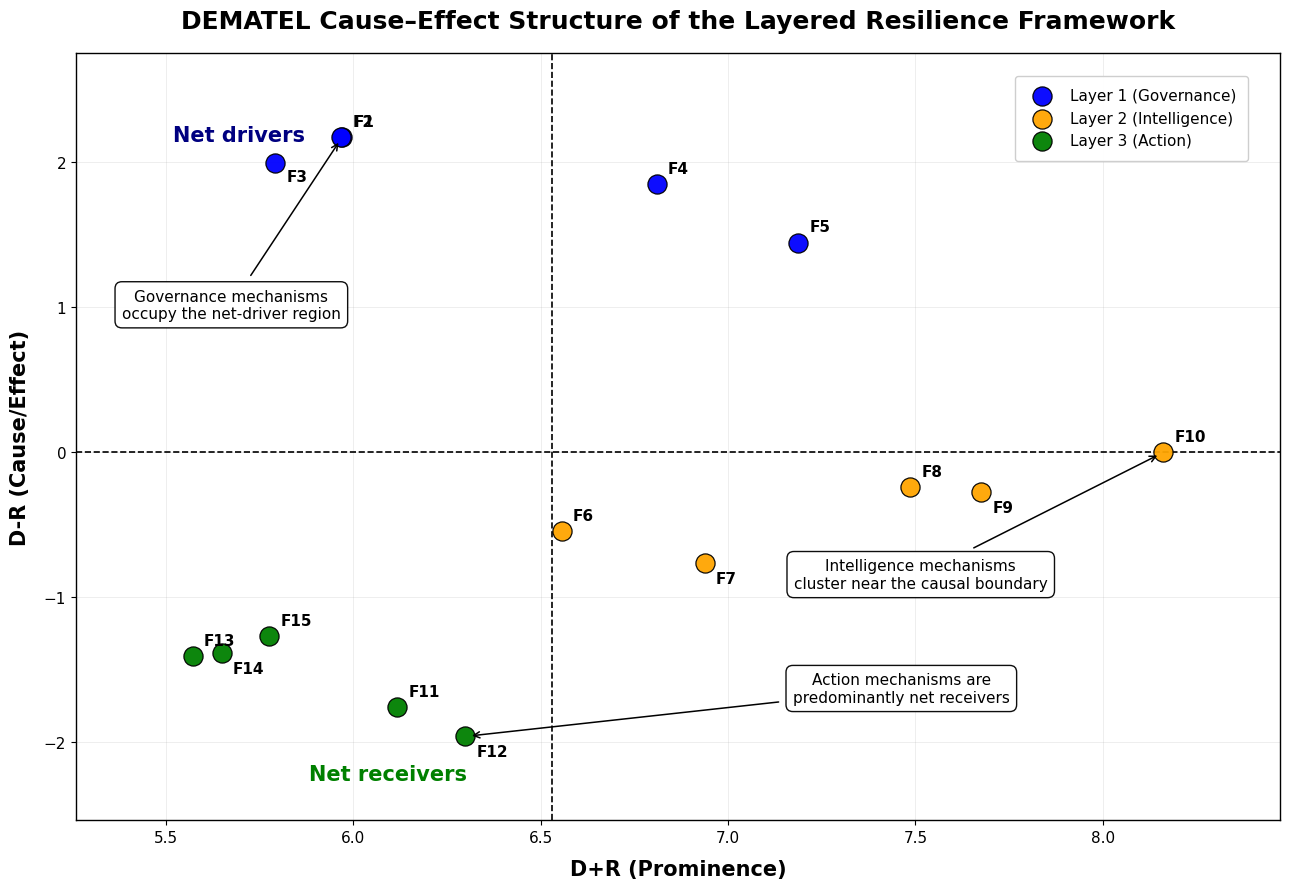

CLEAN DEMATEL FIGURE CREATED

Mean prominence: 6.5308

Saved to:
c:\Users\1886199\OneDrive - UET\Drive G\Data science coding\VSCode programming\DEMATEL analysis and review coding\output\DEMATEL_Cause_Effect_Layered_Clean.png


In [7]:
# ============================================================
# CLEAN PUBLICATION-STYLE DEMATEL CAUSE-EFFECT FIGURE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


# ============================================================
# 1. OUTPUT FOLDER
# ============================================================

OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_FILE = OUTPUT_DIR / "DEMATEL_Cause_Effect_Layered_Clean.png"


# ============================================================
# 2. LAYER DEFINITIONS
# ============================================================

layer_1 = ["F1", "F2", "F3", "F4", "F5"]
layer_2 = ["F6", "F7", "F8", "F9", "F10"]
layer_3 = ["F11", "F12", "F13", "F14", "F15"]


layers = {
    "Layer 1 (Governance)": (layer_1, "blue"),
    "Layer 2 (Intelligence)": (layer_2, "orange"),
    "Layer 3 (Action)": (layer_3, "green")
}


# ============================================================
# 3. CHECK RESULTS DATA
# ============================================================

required_columns = ["Factor", "D+R", "D-R"]

for col in required_columns:
    if col not in results_df.columns:
        raise ValueError(
            f"Column '{col}' is missing from results_df."
        )


plot_df = results_df.copy()

plot_df["D+R"] = pd.to_numeric(
    plot_df["D+R"],
    errors="coerce"
)

plot_df["D-R"] = pd.to_numeric(
    plot_df["D-R"],
    errors="coerce"
)

plot_df = plot_df.dropna(
    subset=["D+R", "D-R"]
)


# ============================================================
# 4. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 9)
)


# ============================================================
# 5. PLOT LAYERS
# ============================================================

for layer_name, (factor_list, color) in layers.items():

    data = plot_df[
        plot_df["Factor"].isin(factor_list)
    ]

    ax.scatter(
        data["D+R"],
        data["D-R"],
        s=190,
        color=color,
        edgecolor="black",
        linewidth=0.9,
        alpha=0.95,
        label=layer_name,
        zorder=5
    )


# ============================================================
# 6. FACTOR LABELS
# ============================================================
#
# Individual offsets prevent labels from sitting directly
# on top of the points.
#
# You can change these later if any two labels remain close.
# ============================================================

label_offsets = {

    "F1": (8, 8),
    "F2": (8, 8),
    "F3": (8, -13),
    "F4": (8, 8),
    "F5": (8, 8),

    "F6": (8, 8),
    "F7": (8, -14),
    "F8": (8, 8),
    "F9": (8, -14),
    "F10": (8, 8),

    "F11": (8, 8),
    "F12": (8, -14),
    "F13": (8, 8),
    "F14": (8, -14),
    "F15": (8, 8)
}


for _, row in plot_df.iterrows():

    factor = row["Factor"]

    dx, dy = label_offsets.get(
        factor,
        (8, 8)
    )

    ax.annotate(

        factor,

        xy=(
            row["D+R"],
            row["D-R"]
        ),

        xytext=(
            dx,
            dy
        ),

        textcoords="offset points",

        fontsize=11,

        fontweight="bold",

        zorder=10
    )


# ============================================================
# 7. ZERO CAUSE/EFFECT LINE
# ============================================================

ax.axhline(

    y=0,

    color="black",

    linestyle="--",

    linewidth=1.2,

    zorder=2
)


# ============================================================
# 8. MEAN PROMINENCE LINE
# ============================================================

mean_prominence = plot_df["D+R"].mean()

ax.axvline(

    x=mean_prominence,

    color="black",

    linestyle="--",

    linewidth=1.2,

    zorder=2
)


# ============================================================
# 9. AXIS LIMITS
# ============================================================

xmin = plot_df["D+R"].min()
xmax = plot_df["D+R"].max()

ymin = plot_df["D-R"].min()
ymax = plot_df["D-R"].max()

xpad = (xmax - xmin) * 0.12
ypad = (ymax - ymin) * 0.14

ax.set_xlim(
    xmin - xpad,
    xmax + xpad
)

ax.set_ylim(
    ymin - ypad,
    ymax + ypad
)


# ============================================================
# 10. NET DRIVER / NET RECEIVER LABELS
# ============================================================

ax.text(

    xmin - 0.02 * (xmax - xmin),

    ymax + 0.02 * (ymax - ymin),

    "Net drivers",

    fontsize=15,

    fontweight="bold",

    color="navy",

    ha="left",

    va="top"
)


ax.text(

    xmin + 0.12 * (xmax - xmin),

    ymin - 0.08 * (ymax - ymin),

    "Net receivers",

    fontsize=15,

    fontweight="bold",

    color="green",

    ha="left",

    va="bottom"
)


# ============================================================
# 11. GOVERNANCE ANNOTATION
# ============================================================

governance = plot_df[
    plot_df["Factor"].isin(layer_1)
]

if len(governance) > 0:

    # Target the upper-left governance cluster
    target = governance.loc[
        governance["D-R"].idxmax()
    ]

    ax.annotate(

        "Governance mechanisms\n"
        "occupy the net-driver region",

        xy=(
            target["D+R"],
            target["D-R"]
        ),

        xytext=(

            xmin + 0.04 * (xmax - xmin),

            ymax - 0.28 * (ymax - ymin)

        ),

        fontsize=11,

        ha="center",

        va="center",

        bbox=dict(

            boxstyle="round,pad=0.45",

            facecolor="white",

            edgecolor="black",

            linewidth=1.0,

            alpha=0.95

        ),

        arrowprops=dict(

            arrowstyle="->",

            color="black",

            linewidth=1.1,

            shrinkA=5,

            shrinkB=5

        ),

        zorder=8
    )


# ============================================================
# 12. INTELLIGENCE ANNOTATION
# ============================================================

intelligence = plot_df[
    plot_df["Factor"].isin(layer_2)
]

if len(intelligence) > 0:

    # Factor closest to D-R = 0
    target = intelligence.loc[
        intelligence["D-R"].abs().idxmin()
    ]

    ax.annotate(

        "Intelligence mechanisms\n"
        "cluster near the causal boundary",

        xy=(
            target["D+R"],
            target["D-R"]
        ),

        xytext=(

            xmax - 0.25 * (xmax - xmin),

            ymin + 0.27 * (ymax - ymin)

        ),

        fontsize=11,

        ha="center",

        va="center",

        bbox=dict(

            boxstyle="round,pad=0.45",

            facecolor="white",

            edgecolor="black",

            linewidth=1.0,

            alpha=0.95

        ),

        arrowprops=dict(

            arrowstyle="->",

            color="black",

            linewidth=1.1,

            shrinkA=5,

            shrinkB=5

        ),

        zorder=8
    )


# ============================================================
# 13. ACTION ANNOTATION
# ============================================================

action = plot_df[
    plot_df["Factor"].isin(layer_3)
]

if len(action) > 0:

    # Target lowest action factor
    target = action.loc[
        action["D-R"].idxmin()
    ]

    ax.annotate(

        "Action mechanisms are\n"
        "predominantly net receivers",

        xy=(
            target["D+R"],
            target["D-R"]
        ),

        xytext=(

            xmax - 0.27 * (xmax - xmin),

            ymin + 0.08 * (ymax - ymin)

        ),

        fontsize=11,

        ha="center",

        va="center",

        bbox=dict(

            boxstyle="round,pad=0.45",

            facecolor="white",

            edgecolor="black",

            linewidth=1.0,

            alpha=0.95

        ),

        arrowprops=dict(

            arrowstyle="->",

            color="black",

            linewidth=1.1,

            shrinkA=5,

            shrinkB=5

        ),

        zorder=8
    )


# ============================================================
# 14. AXIS LABELS
# ============================================================

ax.set_xlabel(

    "D+R (Prominence)",

    fontsize=15,

    fontweight="bold",

    labelpad=10
)


ax.set_ylabel(

    "D-R (Cause/Effect)",

    fontsize=15,

    fontweight="bold",

    labelpad=10
)


# ============================================================
# 15. TITLE
# ============================================================

ax.set_title(

    "DEMATEL Cause–Effect Structure of the Layered Resilience Framework",

    fontsize=18,

    fontweight="bold",

    pad=18
)


# ============================================================
# 16. LEGEND
# ============================================================

ax.legend(

    loc="upper right",

    bbox_to_anchor=(0.98, 0.98),

    fontsize=11,

    frameon=True,

    framealpha=0.95,

    borderpad=0.8

)


# ============================================================
# 17. GRID
# ============================================================

ax.grid(

    True,

    linestyle="-",

    linewidth=0.7,

    alpha=0.22

)


# ============================================================
# 18. TICKS
# ============================================================

ax.tick_params(

    axis="both",

    labelsize=11

)


# ============================================================
# 19. SPINES
# ============================================================

for spine in ax.spines.values():

    spine.set_linewidth(1.0)


# ============================================================
# 20. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 21. SAVE
# ============================================================

plt.savefig(

    FIGURE_FILE,

    dpi=600,

    bbox_inches="tight",

    facecolor="white"

)


# ============================================================
# 22. DISPLAY
# ============================================================

plt.show()


# ============================================================
# 23. CONFIRMATION
# ============================================================

print("=" * 70)
print("CLEAN DEMATEL FIGURE CREATED")
print("=" * 70)
print()
print("Mean prominence:", round(mean_prominence, 4))
print()
print("Saved to:")
print(FIGURE_FILE)